In [55]:
import pandas as pd
import numpy as np
import zipfile


### pytrends dataframe, NY weekly google trends for keywords


In [56]:
# trendspy for google trends
from trendspy import Trends
import pandas as pd

tr = Trends()
keywords = ["asthma attack", "asthma inhaler", "difficulty breathing"]
trendsdf = tr.interest_over_time(keywords, geo='US-NY', timeframe='2024-01-01 2024-12-31')

In [57]:
trendsdf.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53 entries, 2023-12-31 to 2024-12-29
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   asthma attack         53 non-null     int64
 1   asthma inhaler        53 non-null     int64
 2   difficulty breathing  53 non-null     int64
dtypes: int64(3)
memory usage: 1.7 KB


In [58]:
trendsdf.head(10)

,asthma attack,asthma inhaler,difficulty breathing
time [UTC],,,
2023-12-31,55,43,33
2024-01-07,76,90,40
2024-01-14,67,73,61
2024-01-21,25,66,47
2024-01-28,39,74,46
2024-02-04,49,66,63
2024-02-11,49,57,40
2024-02-18,52,49,55
2024-02-25,62,62,44


### CSV containing AQI and air pollution data

In [106]:
# using zipfile module as MAC seems to add an additional csv file when zipping a csv
with zipfile.ZipFile('../data/AQI_Geo2024.zip') as z:
    with z.open('AQI_Geo2024.csv') as f:
        asthmadf = pd.read_csv(f)

/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_1791/2595491703.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  asthmadf = pd.read_csv(f)


In [124]:
il = asthmadf[asthmadf['City Name'] == 'Chicago']
il[il['Method Name'] == "Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric"]

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
209220,17,31,22,88101,1,41.687165,-87.539315,WGS84,PM2.5 - Local Conditions,24 HOUR,...,13.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,WASHINGTON HS,3535 E. 114TH ST.,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-13
209221,17,31,22,88101,1,41.687165,-87.539315,WGS84,PM2.5 - Local Conditions,24 HOUR,...,24.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,WASHINGTON HS,3535 E. 114TH ST.,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-13
209222,17,31,22,88101,1,41.687165,-87.539315,WGS84,PM2.5 - Local Conditions,24 HOUR,...,65.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,WASHINGTON HS,3535 E. 114TH ST.,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-13
209223,17,31,22,88101,1,41.687165,-87.539315,WGS84,PM2.5 - Local Conditions,24 HOUR,...,34.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,WASHINGTON HS,3535 E. 114TH ST.,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-13
209224,17,31,22,88101,1,41.687165,-87.539315,WGS84,PM2.5 - Local Conditions,24 HOUR,...,18.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,WASHINGTON HS,3535 E. 114TH ST.,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209789,17,31,76,88101,1,41.751400,-87.713488,WGS84,PM2.5 - Local Conditions,24 HOUR,...,44.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,COM ED MAINTENANCE BLDG,7801 LAWNDALE,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-07
209790,17,31,76,88101,1,41.751400,-87.713488,WGS84,PM2.5 - Local Conditions,24 HOUR,...,33.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,COM ED MAINTENANCE BLDG,7801 LAWNDALE,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-07
209791,17,31,76,88101,1,41.751400,-87.713488,WGS84,PM2.5 - Local Conditions,24 HOUR,...,60.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,COM ED MAINTENANCE BLDG,7801 LAWNDALE,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-07
209792,17,31,76,88101,1,41.751400,-87.713488,WGS84,PM2.5 - Local Conditions,24 HOUR,...,37.0,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,COM ED MAINTENANCE BLDG,7801 LAWNDALE,Illinois,Cook,Chicago,"Chicago-Naperville-Elgin, IL-IN-WI",2025-02-07


In [60]:
display(asthmadf.shape)
display(asthmadf.isna().sum())
asthmadf.info()
asthmadf['Arithmetic Mean'].describe()

(738478, 29)

State Code                  0
County Code                 0
Site Num                    0
Parameter Code              0
POC                         0
Latitude                    0
Longitude                   0
Datum                       0
Parameter Name              0
Sample Duration             0
Pollutant Standard     341757
Date Local                  0
Units of Measure            0
Event Type             702943
Observation Count           0
Observation Percent         0
Arithmetic Mean             0
1st Max Value               0
1st Max Hour                0
AQI                    341757
Method Code                 0
Method Name                 0
Local Site Name         22694
Address                     0
State Name                  0
County Name                 0
City Name                   0
CBSA Name               57834
Date of Last Change         0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738478 entries, 0 to 738477
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   State Code           738478 non-null  int64  
 1   County Code          738478 non-null  int64  
 2   Site Num             738478 non-null  int64  
 3   Parameter Code       738478 non-null  int64  
 4   POC                  738478 non-null  int64  
 5   Latitude             738478 non-null  float64
 6   Longitude            738478 non-null  float64
 7   Datum                738478 non-null  object 
 8   Parameter Name       738478 non-null  object 
 9   Sample Duration      738478 non-null  object 
 10  Pollutant Standard   396721 non-null  object 
 11  Date Local           738478 non-null  object 
 12  Units of Measure     738478 non-null  object 
 13  Event Type           35535 non-null   object 
 14  Observation Count    738478 non-null  int64  
 15  Observation Perce

count    738478.000000
mean          7.110561
std           5.392473
min          -7.062500
25%           4.000000
50%           6.041667
75%           9.000000
max         833.842857
Name: Arithmetic Mean, dtype: float64

<Axes: >

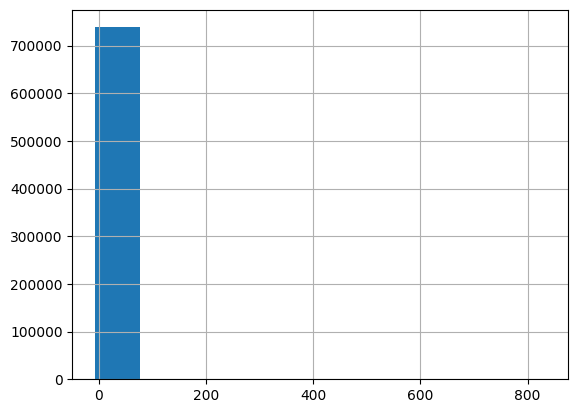

In [61]:
asthmadf['Arithmetic Mean'].hist()

### NYC Asthma Data

In [62]:
# filtered dataframe to be just for new york city
nyasthmadf = asthmadf[(asthmadf['State Name'] == 'New York') & (asthmadf['City Name'] == 'New York')]

In [63]:
display(nyasthmadf.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5227 entries, 442595 to 452652
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State Code           5227 non-null   int64  
 1   County Code          5227 non-null   int64  
 2   Site Num             5227 non-null   int64  
 3   Parameter Code       5227 non-null   int64  
 4   POC                  5227 non-null   int64  
 5   Latitude             5227 non-null   float64
 6   Longitude            5227 non-null   float64
 7   Datum                5227 non-null   object 
 8   Parameter Name       5227 non-null   object 
 9   Sample Duration      5227 non-null   object 
 10  Pollutant Standard   3053 non-null   object 
 11  Date Local           5227 non-null   object 
 12  Units of Measure     5227 non-null   object 
 13  Event Type           0 non-null      object 
 14  Observation Count    5227 non-null   int64  
 15  Observation Percent  5227 non-null  

None

In [64]:
display(nyasthmadf.head(5))

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
442595,36,5,110,88101,1,40.816,-73.902,WGS84,PM2.5 - Local Conditions,24 HOUR,...,44.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,IS 52,IS 52 681 KELLY ST,New York,Bronx,New York,"New York-Newark-Jersey City, NY-NJ-PA",2025-03-21
442596,36,5,110,88101,1,40.816,-73.902,WGS84,PM2.5 - Local Conditions,24 HOUR,...,32.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,IS 52,IS 52 681 KELLY ST,New York,Bronx,New York,"New York-Newark-Jersey City, NY-NJ-PA",2025-03-21
442597,36,5,110,88101,1,40.816,-73.902,WGS84,PM2.5 - Local Conditions,24 HOUR,...,13.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,IS 52,IS 52 681 KELLY ST,New York,Bronx,New York,"New York-Newark-Jersey City, NY-NJ-PA",2025-03-21
442598,36,5,110,88101,1,40.816,-73.902,WGS84,PM2.5 - Local Conditions,24 HOUR,...,13.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,IS 52,IS 52 681 KELLY ST,New York,Bronx,New York,"New York-Newark-Jersey City, NY-NJ-PA",2025-03-21
442599,36,5,110,88101,1,40.816,-73.902,WGS84,PM2.5 - Local Conditions,24 HOUR,...,21.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,IS 52,IS 52 681 KELLY ST,New York,Bronx,New York,"New York-Newark-Jersey City, NY-NJ-PA",2025-03-21


<Axes: >

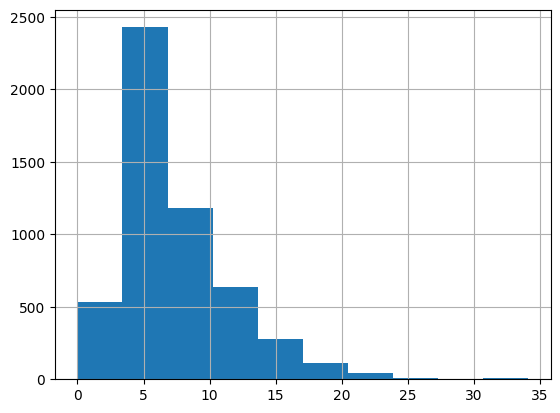

In [65]:
#looks more normal compared to original dataset but is left skewed
display(nyasthmadf['Arithmetic Mean'].hist())

<Axes: >

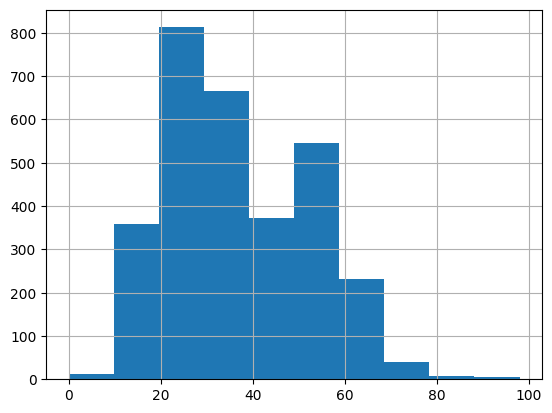

In [66]:
# also very normal
display(nyasthmadf['AQI'].hist())

# PM2.5 PIPELINE

In [ ]:
# FOR PM2.5 DATASET
# ---- CLEANING AND FILTERING
#
columns = ['Date Local','State Name','City Name','County Name','Method Name','Arithmetic Mean','AQI']
# using zipfile module as MAC seems to add an additional csv file when zipping a csv
with zipfile.ZipFile('../data/AQI_Geo2024.zip') as z:
    with z.open('AQI_Geo2024.csv') as f:
        asthmadf = pd.read_csv(f,usecols=columns)
# fixing data types
asthmadf['Date Local'] = pd.to_datetime(asthmadf['Date Local'])
asthmadf[['State Name','City Name','County Name','Method Name']] = asthmadf[['State Name','City Name','County Name','Method Name']].astype('string')

# filtering State and City (although im using NYC, LA, and Chicago, i want to have variables that can be changed if using a different city/state)
states = ['New York', 'California', 'Illinois']
cities = ['New York', 'Los Angeles', 'Chicago']
asthmadf = asthmadf[asthmadf['State Name'].isin(states)]
asthmadf = asthmadf[asthmadf['City Name'].isin(cities)]

# changing the names of 'Kings' and 'Richmond' to formally known names 'Brooklyn' and 'Staten Island'
asthmadf['County Name'] = asthmadf['County Name'].replace({'Kings':'Brooklyn','Richmond':'Staten Island'})

# using the r & p method as it is more reliable (lab tested 24 hour surveillance of PM2.5)
# chicago uses the Met One FRM method which is the equivalent FRM standard
# both are FRM (Federal Reference Method), means it is government approved format for PM2.5 tracking
frm_method = 'R & P Model 2025 PM-2.5 Sequential Air Sampler w/VSCC - Gravimetric'
chicago_method = 'Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric'
asthmadf = asthmadf[
    ((asthmadf['City Name'] == 'Chicago') & (asthmadf['Method Name'] == chicago_method)) |
    ((asthmadf['City Name'] != 'Chicago') & (asthmadf['Method Name'] == frm_method))
]
asthmadf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1658 entries, 53490 to 452652
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date Local       1658 non-null   datetime64[ns]
 1   Arithmetic Mean  1658 non-null   float64       
 2   AQI              1658 non-null   float64       
 3   Method Name      1658 non-null   string        
 4   State Name       1658 non-null   string        
 5   County Name      1658 non-null   string        
 6   City Name        1658 non-null   string        
dtypes: datetime64[ns](1), float64(2), string(4)
memory usage: 103.6 KB


In [200]:
nycdf = asthmadf[asthmadf['City Name'] == 'New York']
ladf = asthmadf[asthmadf['City Name'] == 'Los Angeles']
chicdf = asthmadf[asthmadf['City Name'] == 'Chicago']

nycweeklydf = nycdf.resample('W',on='Date Local').mean(numeric_only=True)
nycweeklydf['city'] = 'New York City'

nycweeklydf

laweeklydf = nycdf.resample('W',on='Date Local').mean(numeric_only=True)
laweeklydf['city'] = 'Los Angeles'

chicweeklydf = nycdf.resample('W',on='Date Local').mean(numeric_only=True)
chicweeklydf['city'] = 'Chicago'

chicweeklydf

fullweeklydf = pd.concat(objs=[nycweeklydf,laweeklydf,chicweeklydf],axis=0)
fullweeklydf = fullweeklydf.reset_index()



# TRENDSPY PIPELINE

In [208]:
from trendspy import Trends
import pandas as pd
import numpy as np
import time

tr = Trends()

cities = {
    'New York City': 'US-NY-501',
    'Los Angeles':   'US-CA-803',
    'Chicago':       'US-IL-602',
}

#"asthma" — general condition awareness
#"air quality" — direct environmental concern
#"shortness of breath" — active symptom response
# all related signals to learn from
keywords = ["asthma", "air quality", "shortness of breath"]
all_data = []

for city, dma_code in cities.items():
    print(f"Querying {city}...")
    try:
        df = tr.interest_over_time(
            keywords,
            geo=dma_code,
            timeframe='2024-01-01 2024-12-31'
        )
        df.replace(0, np.nan, inplace=True)
        df['city'] = city
        all_data.append(df)
        time.sleep(5)
    except Exception as e:
        print(f"  {city} failed: {e}")
        continue

combined = pd.concat(all_data)

# resetting index so its not a date time index
combined = combined.reset_index()


Querying New York City...
Querying Los Angeles...
Querying Chicago...


In [ ]:
# renaming to have the same column name
combined.rename(columns={"time [UTC]":"Date Local"},inplace=True)

['Date Local', 'Arithmetic Mean', 'AQI', 'city']

['Date Local', 'asthma', 'air quality', 'shortness of breath', 'city']

# CLEANING FULL DATAFRAME

In [ ]:
# merging 
fulldf= pd.merge(left=fullweeklydf,right=combined,on=['Date Local','city'])
# im seeing that when air quality's relative search value increasezs to 100, its coinciding with events 

In [ ]:
#organizing the columns
fulldf = fulldf[['Date Local','city','asthma','air quality','shortness of breath','Arithmetic Mean','AQI']]

#rounding means to the 3 sig fig
numeric = ['Arithmetic Mean','AQI']
fulldf[numeric] = round(fulldf[numeric],3)

#renaming mean column so its more legible
fulldf.rename(columns={'Arithmetic Mean':'pm2.5 mean'})


,Date Local,city,asthma,air quality,shortness of breath,pm2.5 mean,AQI
0,2024-01-07,New York City,44,15,8,5.868,32.318
1,2024-01-14,New York City,41,16,9,3.133,17.333
2,2024-01-21,New York City,43,17,9,10.743,53.357
3,2024-01-28,New York City,41,16,9,8.895,43.750
4,2024-02-04,New York City,42,18,11,4.193,23.133
...,...,...,...,...,...,...,...
151,2024-12-01,Chicago,91,24,15,5.493,30.500
152,2024-12-08,Chicago,91,19,22,6.126,33.913
153,2024-12-15,Chicago,71,17,27,5.077,28.154
154,2024-12-22,Chicago,71,26,24,4.493,25.000
